Matched state coverages to simulation p values:


,State,p_target,phi_obs,fV_obs,p_matched,p_difference
0,Arizona,0.886,NaN,0.03,0.886,0.0
1,Utah,0.886,0.33,0.06,0.886,0.0
2,North Dakota,0.900,0.46,0.00,0.900,0.0
3,South Carolina,0.912,0.36,0.03,0.912,0.0
4,Michigan,0.916,0.28,0.07,0.916,0.0
5,Texas,0.932,NaN,0.11,0.932,0.0
6,New Mexico,0.948,NaN,0.21,0.948,0.0


/tmp/ipykernel_6266/2777153149.py:285: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


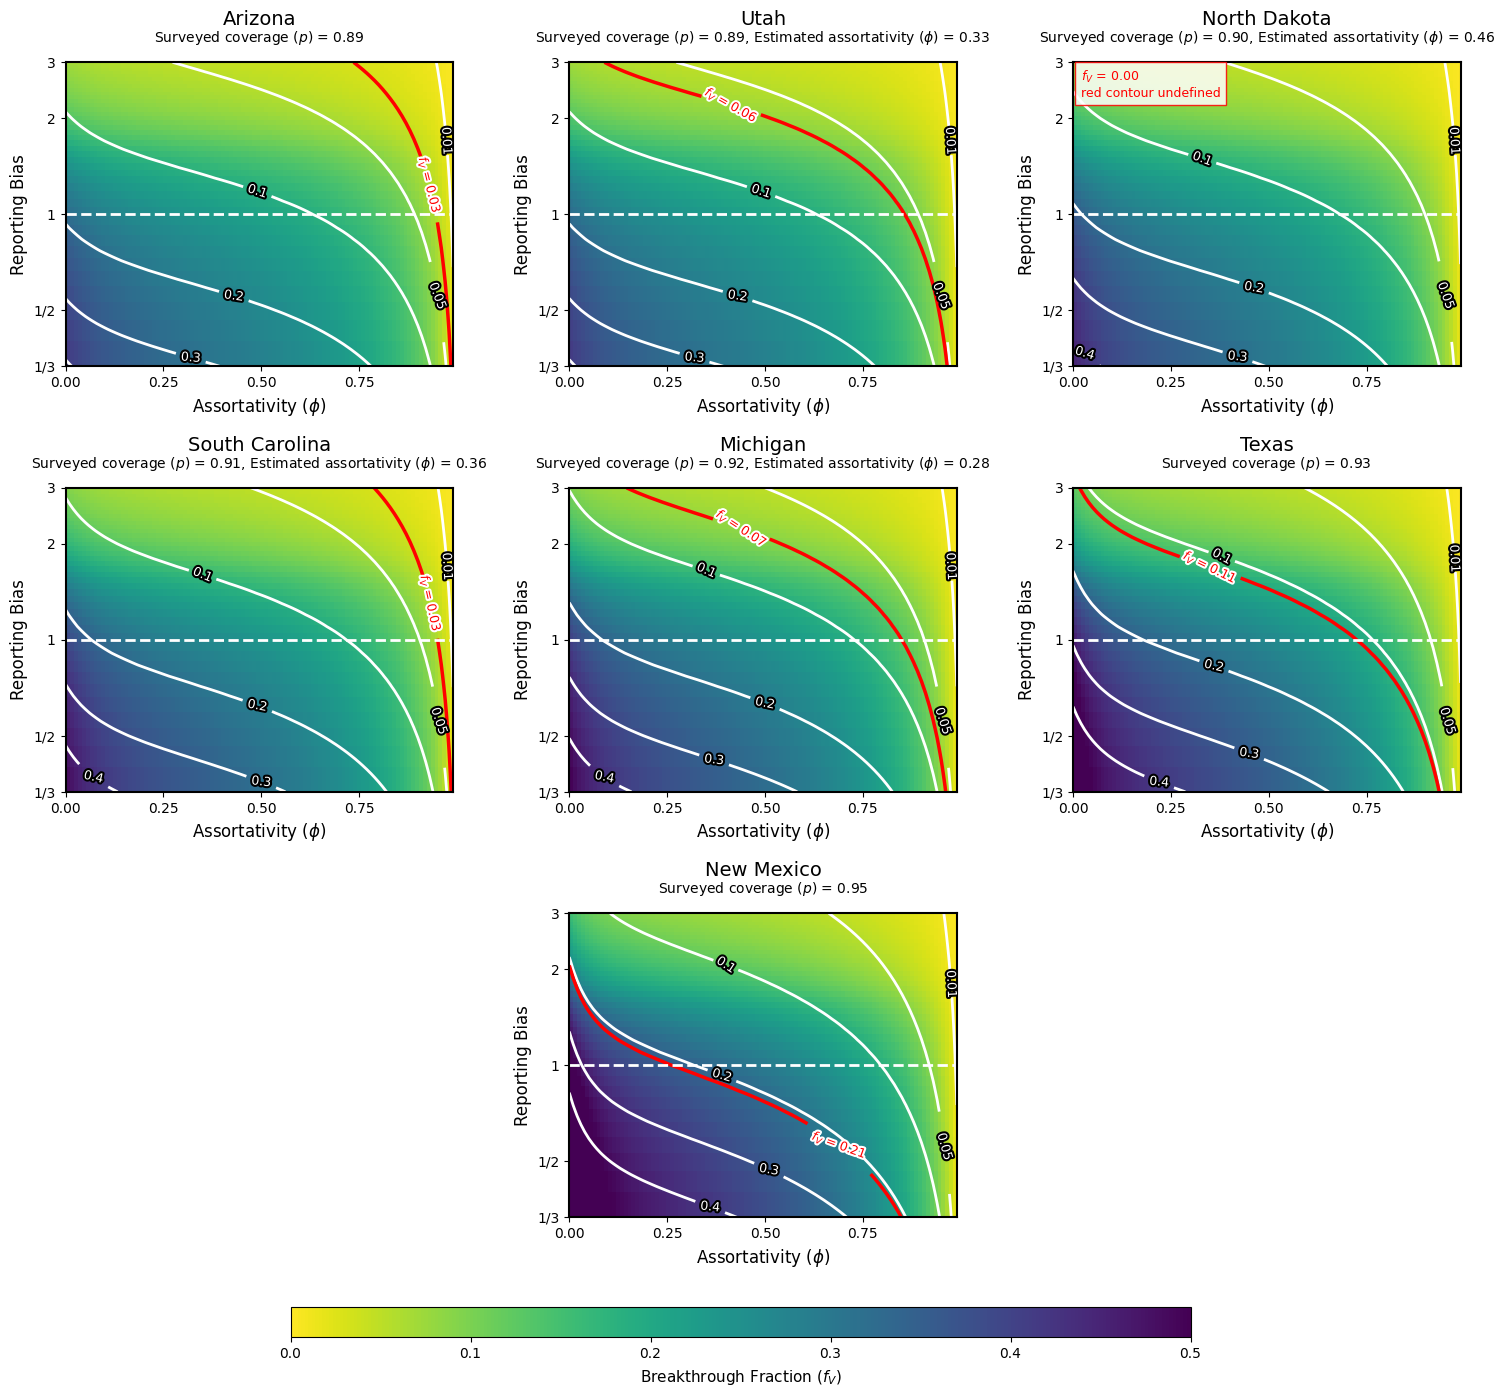

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.colors import PowerNorm
import os
from mpl_toolkits.axes_grid1 import make_axes_locatable # Import for flexible colorbar placement

df = pd.read_csv("../data/generated/manyphi-ode-output.csv").rename(
    columns={
        "coverage": "p",
        "incidence_U": "annual_CU",
        "incidence_V": "annual_CV",
    }
)

# Make sure p is on 0–1 scale
if df["p"].max() > 1:
    df["p"] = df["p"] / 100

df["phi"] = df["phi"].round(2)


# Build underreporting sensitivity dataframe

reporting_fact = np.arange(1, 3.1, 0.1)
reporting_fact = np.concatenate([reporting_fact, (1 / reporting_fact[1:])[::-1]])

underrep_df = (
    pd.MultiIndex.from_product(
        [reporting_fact, sorted(df["p"].unique()), sorted(df["phi"].unique())],
        names=["reporting_fact", "p", "phi"]
    )
    .to_frame(index=False)
    .merge(df, on=["p", "phi"], how="left")
)

underrep_df["IU"] = underrep_df["IU"] * underrep_df["reporting_fact"]
underrep_df["fV"] = underrep_df["IV"] / (underrep_df["IU"] + underrep_df["IV"])
underrep_df = underrep_df[(underrep_df["IU"] + underrep_df["IV"]) >= 1].copy()

# ------------------------------------------------------------------
# State-specific values from your table
# ------------------------------------------------------------------
state_info = pd.DataFrame({
    "State": [
        "Arizona",
        "Michigan",
        "New Mexico",
        "North Dakota",
        "South Carolina",
        "Texas",
        "Utah",
    ],
    "p_target": [
        0.886,
        0.916,
        0.948,
        0.900,
        0.912,
        0.932,
        0.886,
    ],
    "phi_obs": [
        np.nan,   # Arizona
        0.28,     # Michigan
        np.nan,   # New Mexico
        0.46,     # North Dakota
        0.36,     # South Carolina
        np.nan,   # Texas
        0.33,     # Utah
    ],
    "fV_obs": [
        0.03,     # Arizona
        0.07,     # Michigan
        0.21,     # New Mexico
        0.00,     # North Dakota
        0.03,     # South Carolina
        0.11,     # Texas
        0.06,     # Utah
    ],
})

available_p = np.sort(underrep_df["p"].dropna().unique())

state_info["p_matched"] = state_info["p_target"].apply(
    lambda x: available_p[np.argmin(np.abs(available_p - x))]
)
state_info["p_difference"] = state_info["p_matched"] - state_info["p_target"]

print("Matched state coverages to simulation p values:")

# order by p_target
state_info = state_info.sort_values(by="p_target").reset_index(drop=True)
display(state_info)


# Plot settings

contour_levels = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4]

# Fix heatmap scale
vmin = 0.0
vmax = 0.5

# Low values bright; high values dark
norm = PowerNorm(gamma=1, vmin=vmin, vmax=vmax)


# Make a single figure with subplots for all states and save as PDF
num_states = len(state_info)
ncols = 3 # Fixed number of columns

# Calculate actual number of rows needed for the GridSpec
full_rows = num_states // ncols
panels_in_last_row = num_states % ncols
actual_nrows = full_rows if panels_in_last_row == 0 else full_rows + 1

# Create the figure and GridSpec
fig = plt.figure(figsize=(ncols * 6, actual_nrows * 5)) # Slightly larger figure for bigger fonts
gs = fig.add_gridspec(actual_nrows, ncols, wspace=0.3, hspace=0.4) # Add some spacing

# Keep track of the last image object for the colorbar and the Utah axis
im = None
utah_ax = None

for i, (idx, row) in enumerate(state_info.iterrows()):
    state = row["State"]
    p_target = row["p_target"]
    p_val = row["p_matched"]
    phi_obs = row["phi_obs"]
    fV_obs = row["fV_obs"]

    current_row_idx = i // ncols
    current_col_idx = i % ncols

    # Adjust column index for centering if it's the last row and not full
    if current_row_idx == actual_nrows - 1 and panels_in_last_row > 0 and ncols > panels_in_last_row:
        offset_for_centering = (ncols - panels_in_last_row) // 2
        ax = fig.add_subplot(gs[current_row_idx, current_col_idx + offset_for_centering])
    else:
        ax = fig.add_subplot(gs[current_row_idx, current_col_idx])

    sub = underrep_df[np.isclose(underrep_df["p"], p_val)].copy()

    if sub.empty:
        ax.text(0.5, 0.5, f"No data for {state}", transform=ax.transAxes, ha="center", va="center", fontsize=12)
        ax.set_title(f"{state}", fontsize=14)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel("")
        ax.set_ylabel("")
        continue

    heat = (
        sub.pivot_table(
            index="reporting_fact",
            columns="phi",
            values="fV",
            aggfunc="mean"
        )
        .sort_index()
        .sort_index(axis=1)
    )

    x = heat.columns.values
    y = heat.index.values
    Z = heat.values

    # Plotting on ax
    im = ax.imshow(
        Z,
        aspect="auto",
        origin="lower",
        extent=[x.min(), x.max(), y.min(), y.max()],
        cmap="viridis_r",
        norm=norm
    )

    X, Y = np.meshgrid(x, y)

    # Standard white contours
    if np.nanmin(Z) < np.nanmax(Z):
        valid_levels = [
            level for level in contour_levels
            if np.nanmin(Z) <= level <= np.nanmax(Z)
        ]

        if valid_levels:
            cs = ax.contour(
                X, Y, Z,
                levels=valid_levels,
                colors="white",
                linewidths=2
            )

            labels = ax.clabel(
                cs,
                inline=True,
                fontsize=9,
                fmt="%.2g"
            )

            for label in labels:
                label.set_path_effects([
                    pe.withStroke(linewidth=3, foreground="black")
                ])

    # Red contour at observed/calculated fV
    zmin = np.nanmin(Z)
    zmax = np.nanmax(Z)
    red_contour_drawn = False

    if zmin <= fV_obs <= zmax and not np.isclose(zmin, zmax):
        try:
            cs_red = ax.contour(
                X, Y, Z,
                levels=[fV_obs],
                colors="red",
                linewidths=2.5
            )

            red_labels = ax.clabel(
                cs_red,
                inline=True,
                fontsize=9,
                fmt={fV_obs: f"{r'$f_V$'} = {fV_obs:.2f}"}
            )

            for label in red_labels:
                label.set_color("red")
                label.set_path_effects([
                    pe.withStroke(linewidth=3, foreground="white")
                ])

            red_contour_drawn = True

        except Exception:
            red_contour_drawn = False

    if not red_contour_drawn:
        ax.text(
            0.02,
            0.98,
            f"{r'$f_V$'} = {fV_obs:.2f}\nred contour undefined",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=9,
            color="red",
            bbox=dict(facecolor="white", edgecolor="red", alpha=0.85)
        )

    # Title and labels
    if pd.notna(phi_obs):
        title_text = f"{state}"
        subtitle_text = f"{r'Surveyed coverage ($p$)'} = {p_target:.2f}, {r'Estimated assortativity ($\phi$)'} = {phi_obs:.2f}"
    else:
        title_text = f"{state}"
        subtitle_text = f"{r'Surveyed coverage ($p$)'} = {p_target:.2f}"

    ax.set_title(title_text, x=.5, y=1.1, fontsize=14, pad=5)
    ax.text(0.5, 1.05, subtitle_text, transform=ax.transAxes, fontsize=10, ha='center', va='bottom')
    ax.set_xlabel(r"Assortativity ($\phi$)", fontsize=12)
    ax.set_ylabel("Reporting Bias", fontsize=12)

    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(1/3, 3)
    ax.set_yscale('log') # Set y-axis to log scale
    ax.axhline(y=1, color='white', linestyle='--', linewidth=2)


    ax.set_xticks([0, 0.25, 0.5, 0.75])
    ax.set_xticklabels(["0.00", "0.25", "0.50", "0.75"], fontsize=10)

    # Adjusted yticks for log scale, using original values
    ax.set_yticks([1/3, 1/2, 1, 2, 3])
    ax.set_yticklabels(["1/3", "1/2", "1", "2", "3"], fontsize=10)
    ax.minorticks_off()

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

fig.tight_layout()

# Add a single colorbar for the entire figure
cbar_ax = fig.add_axes([0.25, 0.03, 0.50, 0.02]) # [left, bottom, width, height]
cbar = fig.colorbar(
    im, # Use the last `im` created, as norm is the same.
    cax=cbar_ax,
    orientation="horizontal",
    ticks=[0, 0.1, 0.2, 0.3, 0.4, 0.5]
)
cbar.set_label(
    r"Breakthrough Fraction ($f_V$)", # Using raw string for math text
    fontsize=11, # Scaled up
    labelpad=5
)

cbar.ax.tick_params(labelsize=10)

# Save as PDF
pdf_output_filename = "figs/supp-underrep.pdf"
os.makedirs(os.path.dirname(pdf_output_filename), exist_ok=True) # Create directory if it doesn't exist
fig.savefig(pdf_output_filename, format="pdf", bbox_inches="tight")
plt.show()
plt.close(fig)